In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("surajghuwalewala/ham1000-segmentation-and-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 2.59G/2.59G [02:08<00:00, 21.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2
Contents of base_path (/root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions):
['2']
Contents of path (/root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2):
['images', 'masks', 'GroundTruth.csv']


Checking for images in: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/images

Found 10015 image files in total. Displaying samples:


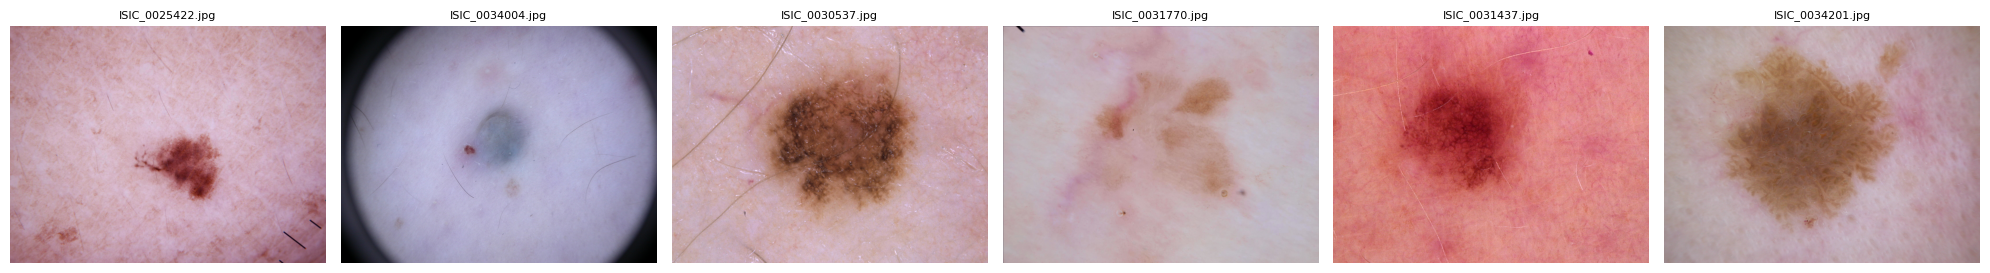

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the root directory containing the images
image_root_dir = os.path.join(path, 'images')

print(f"Checking for images in: {image_root_dir}")
if not os.path.exists(image_root_dir):
    print(f"Error: Directory '{image_root_dir}' not found.")
else:
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    # Scan through the images folder directly
    for root, dirs, files in os.walk(image_root_dir):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if all_image_paths:
        print(f"\nFound {len(all_image_paths)} image files in total. Displaying samples:")

        # Select up to 6 samples to display
        num_samples = min(len(all_image_paths), 6)
        samples_to_display = all_image_paths[:num_samples]

        fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))
        if num_samples == 1:
            axes = [axes]

        for i, img_path in enumerate(samples_to_display):
            try:
                img = Image.open(img_path)
                axes[i].imshow(img)
                # Show the filename
                axes[i].set_title(os.path.basename(img_path), fontsize=8)
                axes[i].axis('off')
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

        plt.tight_layout()
        plt.show()
    else:
        print("\nNo images found in the 'images' folder.")

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os

# Path to the metadata file containing labels
metadata_path = os.path.join(path, 'GroundTruth.csv')

if os.path.exists(metadata_path):
    # Read data from CSV file
    df = pd.read_csv(metadata_path)

    # Split dataset into train (80%) and test (20%)
    # random_state=42 ensures reproducibility
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

    print(f"Total samples: {len(df)}")
    print(f"Training set size: {len(train_df)} (80%)")
    print(f"Testing set size: {len(test_df)} (20%)")

    # Display first few rows of the training set
    display(train_df.head())
else:
    # If no metadata file exists, split based on image paths
    train_paths, test_paths = train_test_split(all_image_paths, test_size=0.2, random_state=42)
    print(f"GroundTruth.csv not found. Splitting directly from image file list:")
    print(f"Training image count: {len(train_paths)}")
    print(f"Testing image count: {len(test_paths)}")

Total samples: 10015
Training set size: 8012 (80%)
Testing set size: 2003 (20%)


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
6582,ISIC_0030888,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7194,ISIC_0031500,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9446,ISIC_0033752,1.0,0.0,0.0,0.0,0.0,0.0,0.0
533,ISIC_0024839,0.0,0.0,0.0,0.0,1.0,0.0,0.0
132,ISIC_0024438,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import torch

# Check if GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available. Using GPU for training.")
else:
    device = torch.device("cpu")
    print("GPU is not available. Using CPU for training.")

GPU is available. Using GPU for training.


### AlexNet Model Definition and Training

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np

In [ ]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=7):  # Assuming 7 classes for skin lesions
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [ ]:
# Data Preprocessing and Loading
# Define the root directory containing the images
image_root_dir = os.path.join(path, 'images')

# Map image_id to full path
image_path_map = {os.path.splitext(os.path.basename(p))[0]: p for p in all_image_paths}

# Create a custom dataset class
class HAM10000Dataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, image_path_map, transform=None):
        self.dataframe = dataframe
        self.image_path_map = image_path_map
        self.transform = transform
        # Identify label columns (exclude 'image')
        self.label_columns = [col for col in self.dataframe.columns if col != 'image']
        # Create mapping for display purposes
        self.label_mapping = {label: idx for idx, label in enumerate(self.label_columns)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Use 'image' instead of 'image_id' based on the dataframe content
        img_name = self.dataframe.iloc[idx]['image']
        img_path = self.image_path_map[img_name]
        image = Image.open(img_path).convert('RGB')

        # Get label by finding which one-hot column is 1.0
        label_row = self.dataframe.iloc[idx][self.label_columns]
        label = np.argmax(label_row.values)

        if self.transform:
            image = self.transform(image)

        return image, label

# Define transformations for the images
transform = transforms.Compose([
    transforms.Resize((224, 224)), # AlexNet expects 224x224 input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet standards
])

# Create dataset instances
train_dataset = HAM10000Dataset(train_df, image_path_map, transform=transform)
test_dataset = HAM10000Dataset(test_df, image_path_map, transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Get the number of classes from the train_dataset
num_classes = len(train_dataset.label_columns)
print(f"Number of classes: {num_classes}")
print(f"Class mapping: {train_dataset.label_mapping}")

Number of classes: 7
Class mapping: {'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}


In [ ]:
model = AlexNet(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_losses = []
test_accuracies = []

print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation on test set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Test Accuracy: {accuracy:.2f}%')

print("Training finished.")

Starting training...
Epoch [1/10], Loss: 1.1536, Test Accuracy: 66.10%
Epoch [2/10], Loss: 0.9499, Test Accuracy: 64.95%
Epoch [3/10], Loss: 0.8822, Test Accuracy: 67.90%
Epoch [4/10], Loss: 0.8773, Test Accuracy: 68.65%
Epoch [5/10], Loss: 0.8504, Test Accuracy: 69.00%
Epoch [6/10], Loss: 0.8505, Test Accuracy: 65.95%
Epoch [7/10], Loss: 0.8937, Test Accuracy: 68.50%
Epoch [8/10], Loss: 0.8269, Test Accuracy: 69.80%
Epoch [9/10], Loss: 0.7960, Test Accuracy: 70.29%
Epoch [10/10], Loss: 0.7792, Test Accuracy: 68.70%
Training finished.


### Training Results Summary

In [ ]:
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")

# Optional: Save the trained model
# torch.save(model.state_dict(), 'alexnet_ham10000.pth')
# print("Model saved to alexnet_ham10000.pth")

Final Training Loss: 0.7792
Final Test Accuracy: 68.70%


### Training Plots

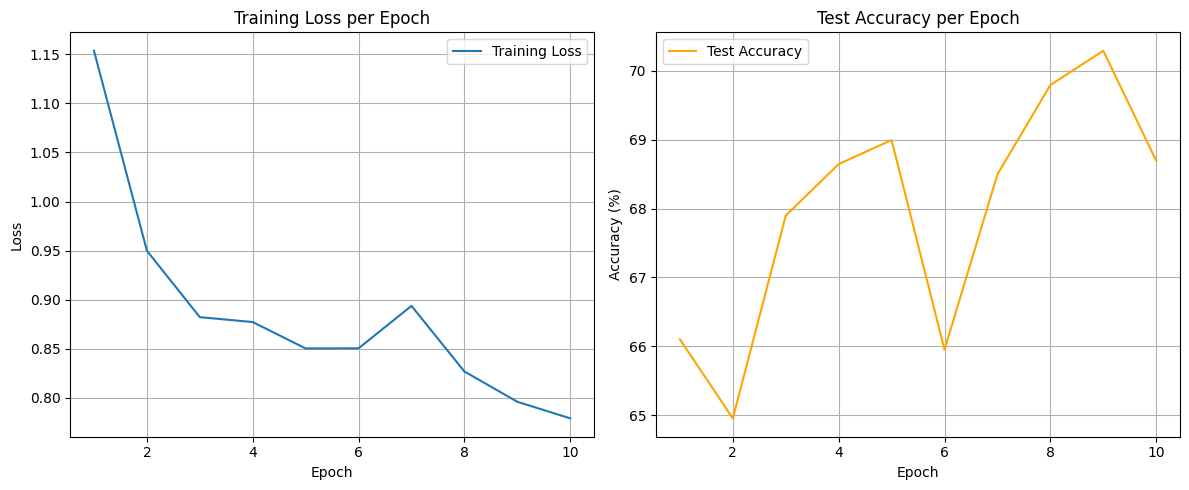

In [ ]:
import matplotlib.pyplot as plt

# Plot training loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()
plt.grid(True)

# Plot test accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy per Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()